# DAIC-WOZ Audio Processing Pipeline
**Goal:** Convert participant-only WAV audio files to log-mel spectrograms for PHQ-8 depression prediction.

Audio files in `./dataset/` are already participant-only (interviewer audio has been removed). No transcript-based slicing is needed.

**Pipeline per participant:**
1. Load train/dev/test label CSVs upfront to build a split lookup
2. Load `{id}_P.wav` directly from `./dataset/`
3. Resample to 16 kHz
4. Segment into fixed-length windows (8 s, 50% overlap)
5. Convert each window to a log-mel spectrogram → save into `spectrograms/train`, `spectrograms/dev`, or `spectrograms/test`
6. Attach PHQ-8 labels into metadata

**Known label issue handled:**
- **Participant 409**: PHQ-8=10 but original binary=0 — corrected automatically.


## Install Dependencies

In [2]:
!pip install librosa soundfile tqdm pandas numpy --quiet
https://github.com/Edgarrighthere/sutd_50.039_Deep_Learning.git
# print success message
print("All packages installed successfully!")

All packages installed successfully!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports & Configuration

In [3]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')


All imports successful!


In [4]:
# Folder containing participant WAV files (e.g. 300_P.wav)
DATASET_DIR = Path('./dataset')

# Output locations
OUTPUT_DIR = Path('./processed')
SPEC_DIR   = OUTPUT_DIR / 'spectrograms'  # subfolders train/dev/test created after split lookup

# Audio parameters
TARGET_SR  = 16_000  # resample target in Hz
WINDOW_SEC = 8.0     # sliding window length in seconds
HOP_SEC    = 4.0     # hop between windows -> 50% overlap

# Minimum audio required to produce at least one window
MIN_SPEECH_SEC = WINDOW_SEC

# Mel-spectrogram parameters
N_FFT      = 1024   # FFT window size
HOP_LENGTH = 160    # STFT hop  — 10 ms @ 16 kHz
WIN_LENGTH = 400    # STFT window — 25 ms @ 16 kHz
N_MELS     = 128    # mel filterbanks
FMIN       = 50     # lowest mel frequency (Hz)
FMAX       = 8_000  # highest mel frequency — Nyquist for 16 kHz

# PHQ-8 binary label correction
LABEL_CORRECTIONS = {409: {'binary_label': 1}}  # score=10 but original binary=0

# Depression threshold
PHQ8_THRESHOLD = 10  # PHQ-8 >= 10 -> depressed (binary label = 1)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')
print(f'  Dataset dir : {DATASET_DIR.resolve()}')
print(f'  Output dir  : {OUTPUT_DIR.resolve()}')
print(f'  Window      : {WINDOW_SEC}s  |  Hop: {HOP_SEC}s  ->  {HOP_SEC/WINDOW_SEC*100:.0f}% overlap')
print(f'  Sample rate : {TARGET_SR} Hz  |  Mels: {N_MELS}')


Configuration loaded.
  Dataset dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\dataset
  Output dir  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed
  Window      : 8.0s  |  Hop: 4.0s  ->  50% overlap
  Sample rate : 16000 Hz  |  Mels: 128


## Discover All Participant WAV Files


In [5]:
wav_files = sorted(DATASET_DIR.glob('*_P.wav'))
if not wav_files:
    raise FileNotFoundError(
        f'No *_P.wav files found in {DATASET_DIR.resolve()}. Update DATASET_DIR above.'
    )

valid_wavs = []
for w in wav_files:
    try:
        pid = int(w.stem.split('_')[0])
        valid_wavs.append((pid, w))
    except ValueError:
        print(f'[SKIP] Cannot parse participant ID from {w.name}')

valid_wavs.sort()
participant_ids = [pid for pid, _ in valid_wavs]

print(f'Found {len(valid_wavs)} participant WAV files')
print(f'ID range : {participant_ids[0]} - {participant_ids[-1]}')


Found 189 participant WAV files
ID range : 300 - 492


## Core Processing Functions

In [ ]:
def segment_waveform(waveform, sr, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    """
    Split waveform into fixed-length overlapping windows.
    Trailing partial window is discarded.
    """
    window_samples = int(window_sec * sr)
    hop_samples    = int(hop_sec * sr)
    segments, start = [], 0
    while start + window_samples <= len(waveform):
        segments.append(waveform[start : start + window_samples])
        start += hop_samples
    return segments

def waveform_to_logmel(segment, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX):
    """
    Convert a waveform segment to a standardised log-mel spectrogram.
    Returns array of shape (N_MELS, T), dtype float32, with mean=0 and std=1.
    """
    mel = librosa.feature.melspectrogram(
        y=segment, sr=sr, n_fft=n_fft, hop_length=hop_length,
        win_length=win_length, n_mels=n_mels, fmin=fmin, fmax=fmax
    )
    log_mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-6)
    return log_mel

print('Processing functions defined!')


Processing functions defined!


## Visualise a Single Example (Sanity Check)
Loads the first participant WAV, shows the waveform and the log-mel spectrogram of the first window.


Visualising participant 300 from 300_P.wav ...
  Duration  : 155.8s
  Windows   : 37
  Spec shape: (128, 801)


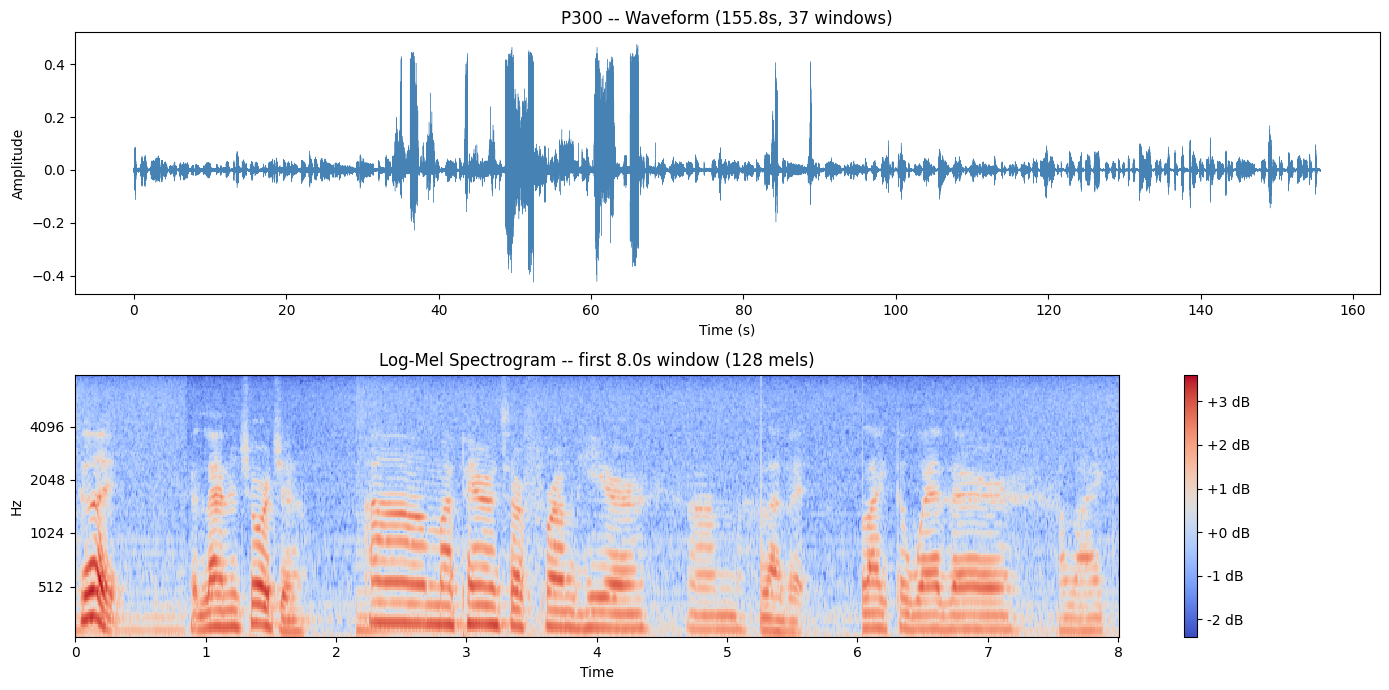

Sanity-check passed.


In [7]:
sample_pid, sample_wav = valid_wavs[0]
print(f'Visualising participant {sample_pid} from {sample_wav.name} ...')

waveform, sr = librosa.load(sample_wav, sr=TARGET_SR, mono=True)
duration     = len(waveform) / sr

segments = segment_waveform(waveform, sr)
log_mel  = waveform_to_logmel(segments[0])

print(f'  Duration  : {duration:.1f}s')
print(f'  Windows   : {len(segments)}')
print(f'  Spec shape: {log_mel.shape}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

t = np.linspace(0, duration, len(waveform))
axes[0].plot(t, waveform, lw=0.3, color='steelblue')
axes[0].set_title(f'P{sample_pid} -- Waveform ({duration:.1f}s, {len(segments)} windows)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

img = librosa.display.specshow(
    log_mel, sr=sr, hop_length=HOP_LENGTH,
    x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX, ax=axes[1]
)
axes[1].set_title(f'Log-Mel Spectrogram -- first {WINDOW_SEC}s window ({N_MELS} mels)')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()
print('Sanity-check passed.')


## Load Labels & Build Split Lookup

Labels are loaded **before** processing so each participant's split is known at save time,
allowing spectrograms to be written directly into `spectrograms/train`, `spectrograms/dev`, or `spectrograms/test`.

The known label error for participant 409 (PHQ-8=10 but original binary=0) is corrected automatically.

In [8]:
# Point these at your label CSVs
TRAIN_LABELS_CSV = Path('./dataset/train_split_Depression_AVEC2017.csv')
DEV_LABELS_CSV = Path('./dataset/dev_split_Depression_AVEC2017.csv')
TEST_LABELS_CSV = Path('./dataset/full_test_split.csv')

def load_label_csv(csv_path, split_name):
    if csv_path is None or not csv_path.exists():
        print(f'  [{split_name}] Not found at {csv_path} — skipping.')
        return pd.DataFrame(columns=['Participant_ID', 'PHQ_Score', 'split'])
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    col_map = {}
    for col in df.columns:
        lc = col.lower()
        if 'participant' in lc:            col_map[col] = 'Participant_ID'
        if 'phq' in lc and 'score' in lc: col_map[col] = 'PHQ_Score'
    df.rename(columns=col_map, inplace=True)
    df['split'] = split_name
    print(f'  [{split_name}] Loaded {len(df)} participants from {csv_path.name}')
    return df[['Participant_ID', 'PHQ_Score', 'split']]

labels_df = pd.concat([
    load_label_csv(TRAIN_LABELS_CSV, 'train'),
    load_label_csv(DEV_LABELS_CSV,   'dev'),
    load_label_csv(TEST_LABELS_CSV,  'test'),
], ignore_index=True)

labels_df['Participant_ID'] = labels_df['Participant_ID'].astype(int)
labels_df['binary_label']   = (labels_df['PHQ_Score'] >= PHQ8_THRESHOLD).astype('Int64')

# Apply known label corrections
for pid, corrections in LABEL_CORRECTIONS.items():
    mask = labels_df['Participant_ID'] == pid
    if mask.any():
        for col, val in corrections.items():
            labels_df.loc[mask, col] = val
        print(f'  [CORRECTION] Applied label fix for P{pid}: {corrections}')

# Build lookup: pid -> {phq_score, binary_label, split}
label_lookup = {
    int(r['Participant_ID']): {
        'phq_score':    float(r['PHQ_Score']) if pd.notna(r.get('PHQ_Score')) else None,
        'binary_label': int(r['binary_label']) if pd.notna(r.get('binary_label')) else None,
        'split':        r['split'],
    }
    for _, r in labels_df.iterrows()
}

# Create split subfolders now that we know which splits exist
for split_name in labels_df['split'].unique():
    (SPEC_DIR / split_name).mkdir(parents=True, exist_ok=True)

print(f'\nLabels loaded: {len(label_lookup)} participants')
print(f'Split counts  : {labels_df["split"].value_counts().to_dict()}')
if 'PHQ_Score' in labels_df.columns:
    print(f'PHQ-8 summary :\n{labels_df["PHQ_Score"].dropna().describe().round(2)}')
    print(f'High-risk (>={PHQ8_THRESHOLD}): {labels_df["binary_label"].sum()} / {labels_df["binary_label"].count()}')
print(f'\nSpectrogram subfolders created:')
for p in sorted(SPEC_DIR.iterdir()):
    print(f'  {p}')

  [train] Loaded 107 participants from train_split_Depression_AVEC2017.csv
  [dev] Loaded 35 participants from dev_split_Depression_AVEC2017.csv
  [test] Loaded 47 participants from full_test_split.csv
  [CORRECTION] Applied label fix for P409: {'binary_label': 1}

Labels loaded: 189 participants
Split counts  : {'train': 107, 'test': 47, 'dev': 35}
PHQ-8 summary :
count    189.00
mean       6.75
std        5.92
min        0.00
25%        2.00
50%        5.00
75%       10.00
max       23.00
Name: PHQ_Score, dtype: float64
High-risk (>=10): 57 / 189

Spectrogram subfolders created:
  processed\spectrograms\dev
  processed\spectrograms\test
  processed\spectrograms\train


## Process ALL Participants

For each WAV file:
- Loads audio directly (already participant-only)
- Skips participants whose audio is shorter than one window
- Segments into 8-second windows with 50% overlap
- Converts each window to a log-mel spectrogram and saves as `.npy`


In [9]:
metadata_rows = []
skipped       = []  # list of (pid, reason)

for pid, wav_path in tqdm(valid_wavs, desc='Processing participants'):

    # Load waveform
    try:
        waveform, sr = librosa.load(wav_path, sr=TARGET_SR, mono=True)
    except Exception as e:
        skipped.append((pid, f'audio load error: {e}'))
        continue

    duration = len(waveform) / sr

    # Skip if too short
    if duration < MIN_SPEECH_SEC:
        skipped.append((pid, f'only {duration:.1f}s audio (< {MIN_SPEECH_SEC}s)'))
        continue

    # Segment into windows
    segments = segment_waveform(waveform, sr)
    if not segments:
        skipped.append((pid, 'no complete windows after segmentation'))
        continue

    # Resolve split and labels
    info         = label_lookup.get(pid, {})
    split        = info.get('split', 'unknown')
    phq_score    = info.get('phq_score', None)
    binary_label = info.get('binary_label', None)

    split_dir = SPEC_DIR / split
    split_dir.mkdir(parents=True, exist_ok=True)

    # Convert each segment -> log-mel -> .npy
    for seg_idx, segment in enumerate(segments):
        log_mel   = waveform_to_logmel(segment)
        save_path = split_dir / f'{pid}_seg{seg_idx:04d}.npy'
        np.save(save_path, log_mel)

        metadata_rows.append({
            'participant_id':   pid,
            'segment_idx':      seg_idx,
            'spectrogram_path': str(save_path),
            'n_mels':           log_mel.shape[0],
            'n_frames':         log_mel.shape[1],
            'duration_s':       round(duration, 2),
            'phq_score':        phq_score,
            'binary_label':     binary_label,
            'split':            split,
        })

processed_pids = sorted({r['participant_id'] for r in metadata_rows})
print(f'\nDone.')
print(f'  Processed      : {len(processed_pids)} participants')
print(f'  Total segments : {len(metadata_rows)}')
print(f'  Skipped        : {len(skipped)}')
if skipped:
    for pid, reason in skipped[:10]:
        print(f'    P{pid}: {reason}')


Processing participants: 100%|██████████| 189/189 [03:26<00:00,  1.09s/it]


Done.
  Processed      : 189 participants
  Total segments : 21588
  Skipped        : 0


## Save Metadata CSV

In [10]:
metadata_df   = pd.DataFrame(metadata_rows)
metadata_path = OUTPUT_DIR / 'segment_metadata.csv'
metadata_df.to_csv(metadata_path, index=False)

print(f'Metadata saved -> {metadata_path}')
print(f'Shape  : {metadata_df.shape}')
print(f'\nColumns: {list(metadata_df.columns)}')
print(f'\nSegments per split:')
print(metadata_df['split'].value_counts(dropna=False))
print(f'\nSpectrogram folder contents:')
for split_dir in sorted(SPEC_DIR.iterdir()):
    n = len(list(split_dir.glob('*.npy')))
    print(f'  {split_dir}  ->  {n} files')
metadata_df.head(8)


Metadata saved -> processed\segment_metadata.csv
Shape  : (21588, 9)

Columns: ['participant_id', 'segment_idx', 'spectrogram_path', 'n_mels', 'n_frames', 'duration_s', 'phq_score', 'binary_label', 'split']

Segments per split:
split
train    11362
test      5904
dev       4322
Name: count, dtype: int64

Spectrogram folder contents:
  processed\spectrograms\dev  ->  4322 files
  processed\spectrograms\test  ->  5904 files
  processed\spectrograms\train  ->  11362 files


,participant_id,segment_idx,spectrogram_path,n_mels,n_frames,duration_s,phq_score,binary_label,split
0,300,0,processed\spectrograms\test\300_seg0000.npy,128,801,155.76,2.0,0,test
1,300,1,processed\spectrograms\test\300_seg0001.npy,128,801,155.76,2.0,0,test
2,300,2,processed\spectrograms\test\300_seg0002.npy,128,801,155.76,2.0,0,test
3,300,3,processed\spectrograms\test\300_seg0003.npy,128,801,155.76,2.0,0,test
4,300,4,processed\spectrograms\test\300_seg0004.npy,128,801,155.76,2.0,0,test
5,300,5,processed\spectrograms\test\300_seg0005.npy,128,801,155.76,2.0,0,test
6,300,6,processed\spectrograms\test\300_seg0006.npy,128,801,155.76,2.0,0,test
7,300,7,processed\spectrograms\test\300_seg0007.npy,128,801,155.76,2.0,0,test


## Dataset Statistics

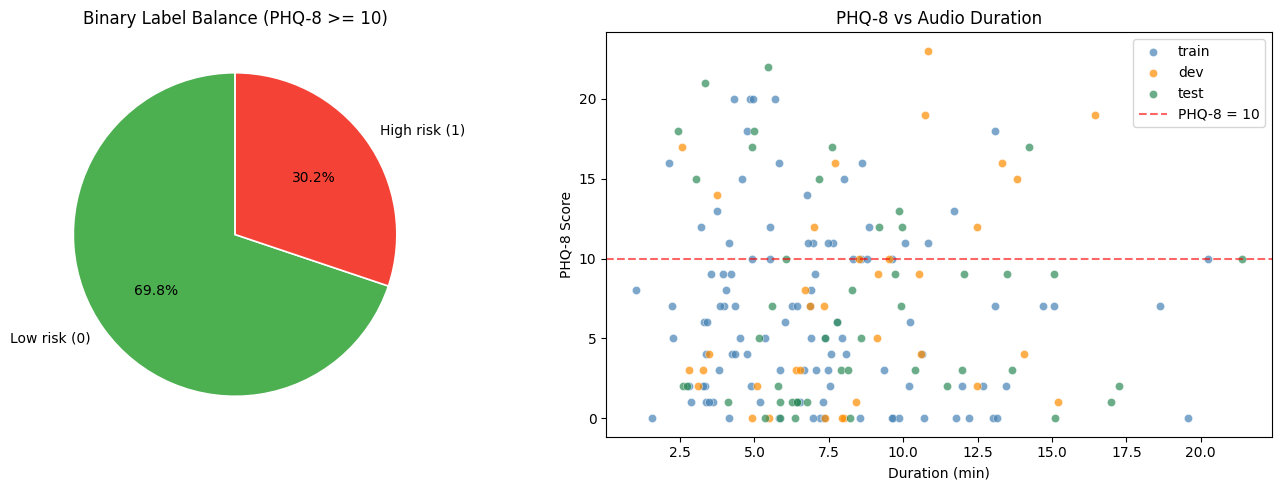

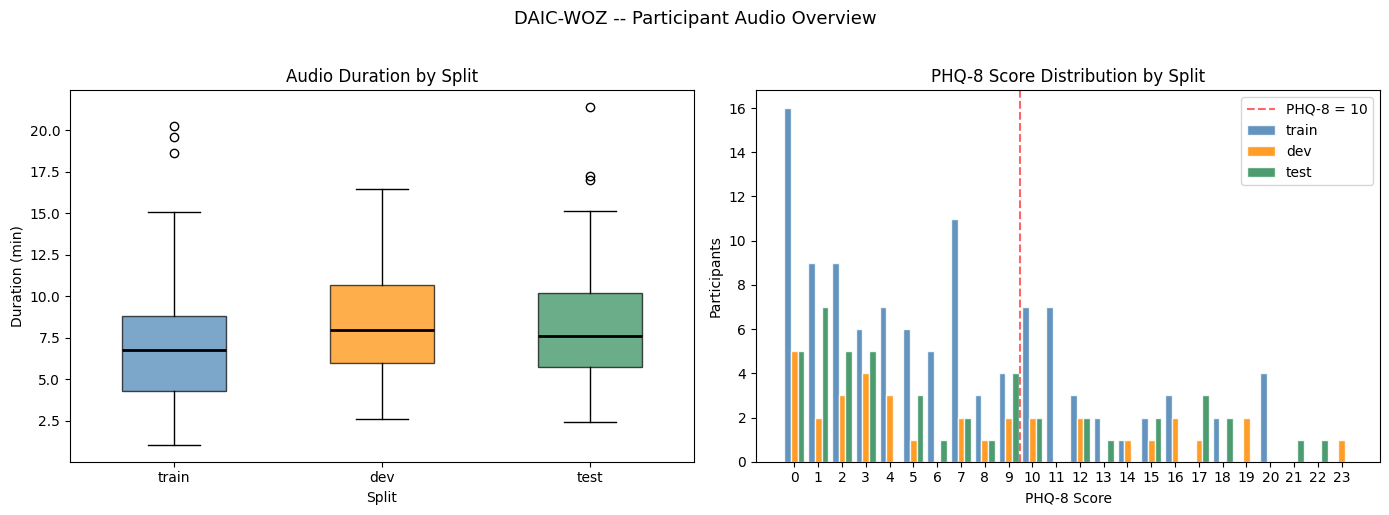

      phq_score                                        duration_s          \
          count  mean   std  min  25%  50%   75%   max      count    mean   
split                                                                       
dev        35.0  7.43  6.59  0.0  2.0  5.0  12.0  23.0       35.0  500.00   
test       47.0  6.98  6.47  0.0  1.5  5.0  11.0  22.0       47.0  508.66   
train     107.0  6.42  5.46  0.0  2.0  6.0  10.0  20.0      107.0  430.56   

                                                        
          std     min     25%     50%     75%      max  
split                                                   
dev    222.54  154.96  356.61  476.22  640.12   987.24  
test   254.65  146.38  342.58  457.25  611.45  1282.82  
train  226.21   62.23  256.30  406.88  529.00  1214.89  


In [11]:
labelled_df = metadata_df.dropna(subset=['phq_score'])

per_participant = labelled_df.groupby('participant_id').agg(
    n_segments   =('segment_idx',  'count'),
    phq_score    =('phq_score',    'first'),
    binary_label =('binary_label', 'first'),
    split        =('split',        'first'),
    duration_s   =('duration_s',   'first'),
).reset_index()

split_colors   = {'train': 'steelblue', 'dev': 'darkorange', 'test': 'seagreen'}
splits_ordered = ['train', 'dev', 'test']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary label balance (pie)
counts = per_participant['binary_label'].value_counts().sort_index()
labels = ['Low risk (0)', 'High risk (1)']
axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.2))
axes[0].set_title(f'Binary Label Balance (PHQ-8 >= {PHQ8_THRESHOLD})', fontsize=12)

# PHQ-8 vs audio duration scatter
for split in splits_ordered:
    grp = per_participant[per_participant['split'] == split]
    axes[1].scatter(grp['duration_s'] / 60, grp['phq_score'],
                    alpha=0.7, label=split, color=split_colors[split], s=35,
                    edgecolors='white', linewidths=0.4)
axes[1].axhline(PHQ8_THRESHOLD, color='red', linestyle='--', alpha=0.6,
                label=f'PHQ-8 = {PHQ8_THRESHOLD}')
axes[1].set_title('PHQ-8 vs Audio Duration', fontsize=12)
axes[1].set_xlabel('Duration (min)')
axes[1].set_ylabel('PHQ-8 Score')
axes[1].legend()

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Duration by split (box plot)
dur_data = [per_participant[per_participant['split'] == s]['duration_s'].values / 60
            for s in splits_ordered]
bp = axes2[0].boxplot(dur_data, labels=splits_ordered, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2))
for patch, split in zip(bp['boxes'], splits_ordered):
    patch.set_facecolor(split_colors[split])
    patch.set_alpha(0.7)
axes2[0].set_title('Audio Duration by Split', fontsize=12)
axes2[0].set_xlabel('Split')
axes2[0].set_ylabel('Duration (min)')

# PHQ-8 score histogram by split
all_scores = per_participant['phq_score']
x          = list(range(int(all_scores.min()), int(all_scores.max()) + 1))
bar_width  = 0.28
offsets    = [-bar_width, 0, bar_width]
for i, split in enumerate(splits_ordered):
    grp = per_participant[per_participant['split'] == split]
    counts_phq = grp['phq_score'].value_counts().reindex(x, fill_value=0)
    axes2[1].bar([v + offsets[i] for v in x], counts_phq.values,
                 width=bar_width, label=split, color=split_colors[split],
                 alpha=0.85, edgecolor='white')
axes2[1].axvline(PHQ8_THRESHOLD - 0.5, color='red', linestyle='--', alpha=0.6,
                 label=f'PHQ-8 = {PHQ8_THRESHOLD}')
axes2[1].set_title('PHQ-8 Score Distribution by Split', fontsize=12)
axes2[1].set_xlabel('PHQ-8 Score')
axes2[1].set_ylabel('Participants')
axes2[1].legend()
axes2[1].set_xticks(x)

plt.suptitle('DAIC-WOZ -- Participant Audio Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(per_participant.groupby('split')[['phq_score', 'duration_s']].describe().round(2))


## Sanity-Check: Load a Saved Spectrogram

Participant 337 | Segment 224
  Shape       : (128, 801)  (n_mels x time_frames)
  dtype       : float32
  Value range : [-1.6, 3.1] dB
  PHQ-8       : 10  |  High risk  |  split: test
  Duration    : 1282.82s


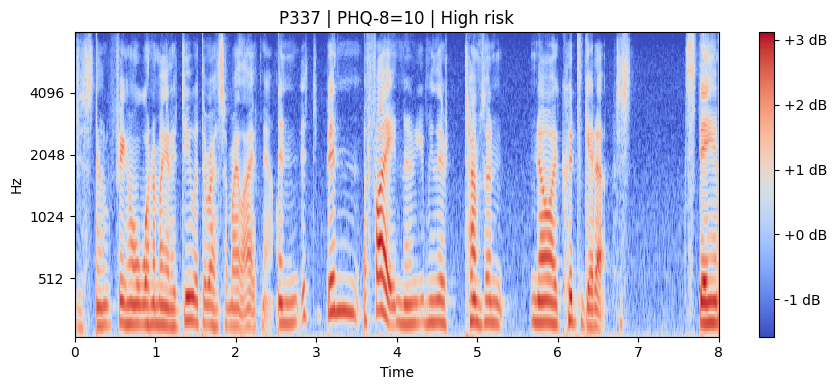


Round-trip check passed.


In [12]:
if len(metadata_rows) > 0:
    sample_row = metadata_df.sample(1).iloc[0]
    loaded     = np.load(sample_row['spectrogram_path'])

    phq_str  = f"{sample_row['phq_score']:.0f}" if pd.notna(sample_row['phq_score']) else 'N/A'
    risk_str = ('High risk' if sample_row['binary_label'] == 1
                else 'Low risk' if sample_row['binary_label'] == 0
                else 'unlabelled')

    print(f'Participant {int(sample_row["participant_id"])} | Segment {int(sample_row["segment_idx"])}')
    print(f'  Shape       : {loaded.shape}  (n_mels x time_frames)')
    print(f'  dtype       : {loaded.dtype}')
    print(f'  Value range : [{loaded.min():.1f}, {loaded.max():.1f}] dB')
    print(f'  PHQ-8       : {phq_str}  |  {risk_str}  |  split: {sample_row["split"]}')
    print(f'  Duration    : {sample_row["duration_s"]}s')

    fig, ax = plt.subplots(figsize=(9, 4))
    librosa.display.specshow(loaded, sr=TARGET_SR, hop_length=HOP_LENGTH,
                             x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX, ax=ax)
    ax.set_title(f'P{int(sample_row["participant_id"])} | PHQ-8={phq_str} | {risk_str}')
    plt.colorbar(ax.collections[0], ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
    print('\nRound-trip check passed.')
else:
    print('[WARN] No segments processed. Check DATASET_DIR.')


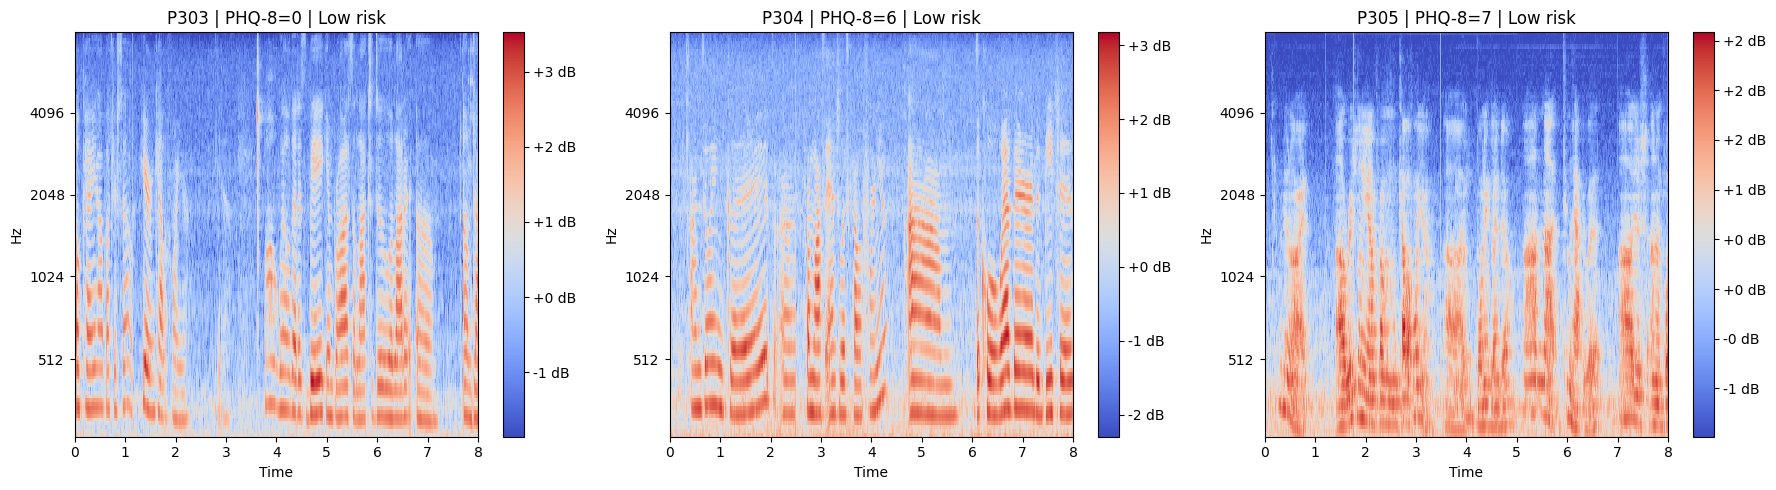

In [13]:
# plot the first 3 samples of loaded spectrograms from train 
train_samples = per_participant[per_participant['split'] == 'train'].head(3)
if train_samples.empty:
    print('[WARN] No training samples found in metadata.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (_, row) in enumerate(train_samples.iterrows()):
        spect_path = SPEC_DIR / row['split'] / f"{row['participant_id']}_seg0000.npy"
        if spect_path.exists():
            spect = np.load(spect_path)
            img = librosa.display.specshow(spect, sr=TARGET_SR, hop_length=HOP_LENGTH,
                                           x_axis='time', y_axis='mel', fmin=FMIN, fmax=FMAX, ax=axes[i])
            axes[i].set_title(f'P{int(row["participant_id"])} | PHQ-8={row["phq_score"]:.0f} | {"High risk" if row["binary_label"] == 1 else "Low risk"}')
            fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
        else:
            axes[i].text(0.5, 0.5, 'Spectrogram not found', ha='center', va='center')
            axes[i].set_title(f'P{int(row["participant_id"])} | Spectrogram missing')
    plt.tight_layout()
    plt.show()
    